# Моделирование геометрической вероятности: Метание топора в яблоко

**Условие:**
Цирковой метатель бросает топор в сторону деревянного щита-мишени, перед которым стоит ассистент с яблоком на голове.

Топор вонзается в случайную точку щита. Нам не важно, попадем мы в человека или нет, самое главное — **попадем ли мы в яблоко**.

**Цель работы:**
Смоделировать броски топора прямо поверх сгенерированного рисунка и доказать: **чем чаще бросаешь топор, тем точнее частота попаданий приближается к теоретической вероятности** (Закон больших чисел).

In [1]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

## 1. Теоретический расчет

In [2]:
# Координаты щита и яблока на картине (в пикселях)
bx, by, bw, bh = 285, 240, 450, 635
x0, y0, r_apple = 510, 353, 22

# Площади
s_board = bw * bh
s_apple = np.pi * (r_apple ** 2)

# Теоретическая вероятность
p_theor = s_apple / s_board

print("Площадь щита:   ", s_board, "кв. px")
print(f"Площадь яблока: {s_apple:.2f} кв. px")
print(f"Теоретическая вероятность: P = {p_theor:.5f} ({p_theor * 100:.3f}%)")

Площадь щита:    285750 кв. px
Площадь яблока: 1520.53 кв. px
Теоретическая вероятность: P = 0.00532 (0.532%)


## 2. Моделирование бросков прямо поверх рисунка ИИ

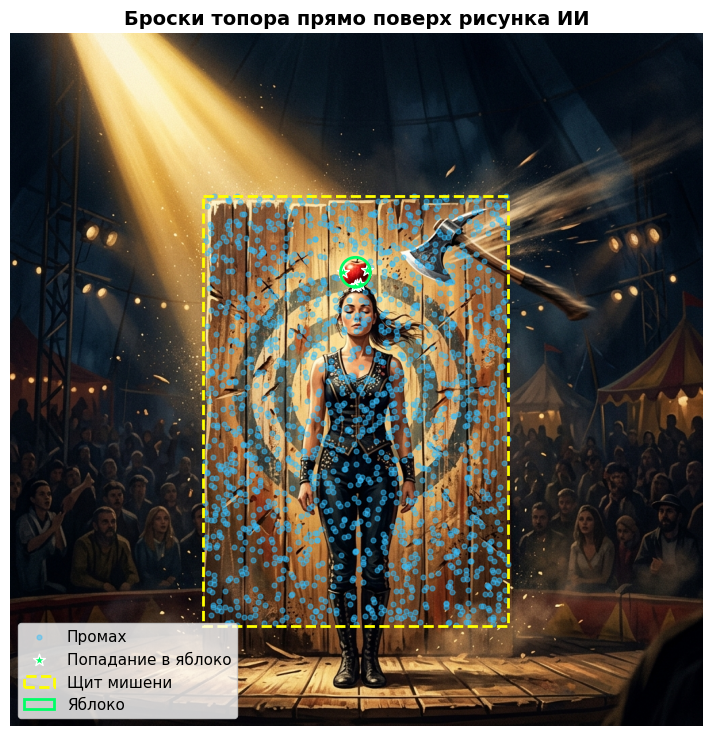

In [3]:
# Загружаем рисунок трюка
img = Image.open('axe_target.jpg')

# Моделируем броски топора
np.random.seed(42)
N_plot = 1500
x_plot = np.random.uniform(bx, bx + bw, N_plot)
y_plot = np.random.uniform(by, by + bh, N_plot)

# Проверка попадания в яблоко: (x - x0)^2 + (y - y0)^2 <= r^2
is_hit = ((x_plot - x0)**2 + (y_plot - y0)**2) <= r_apple**2

# Отображаем прямо поверх рисунка ИИ
plt.figure(figsize=(9, 9))
plt.imshow(img)

# Точки попаданий и промахов
plt.scatter(x_plot[~is_hit], y_plot[~is_hit], color='#38bdf8', s=12, alpha=0.45, label='Промах')
plt.scatter(x_plot[is_hit], y_plot[is_hit], color='#00ff66', s=80, marker='*', edgecolors='white', label='Попадание в яблоко')

# Рамка щита и контур яблока
board_rect = plt.Rectangle((bx, by), bw, bh, fill=False, edgecolor='yellow', linestyle='--', lw=2, label='Щит мишени')
apple_circ = plt.Circle((x0, y0), r_apple, fill=False, edgecolor='#00ff66', lw=2, label='Яблоко')
plt.gca().add_patch(board_rect)
plt.gca().add_patch(apple_circ)

plt.title("Броски топора прямо поверх рисунка ИИ", fontsize=14, fontweight="bold")
plt.axis('off')
plt.legend(loc='lower left', fontsize=11)
plt.show()

## 3. Доказательство: чем чаще бросаешь, тем точнее циферка

In [4]:
# Проверяем, как меняется точность при росте числа бросков N
np.random.seed(42)

for N in [10, 100, 1000, 10000, 100000]:
    x = np.random.uniform(bx, bx + bw, N)
    y = np.random.uniform(by, by + bh, N)
    
    hits = np.sum(((x - x0)**2 + (y - y0)**2) <= r_apple**2)
    freq = hits / N
    err = abs(freq - p_theor)
    
    print(f"Бросков: {N:>6} | Попаданий: {hits:>4} | Частота: {freq:.5f} | Ошибка: {err:.5f}")

Бросков:     10 | Попаданий:    0 | Частота: 0.00000 | Ошибка: 0.00532
Бросков:    100 | Попаданий:    0 | Частота: 0.00000 | Ошибка: 0.00532
Бросков:   1000 | Попаданий:    4 | Частота: 0.00400 | Ошибка: 0.00132
Бросков:  10000 | Попаданий:   53 | Частота: 0.00530 | Ошибка: 0.00002
Бросков: 100000 | Попаданий:  544 | Частота: 0.00544 | Ошибка: 0.00012


## 4. График сходимости (Закон больших чисел)

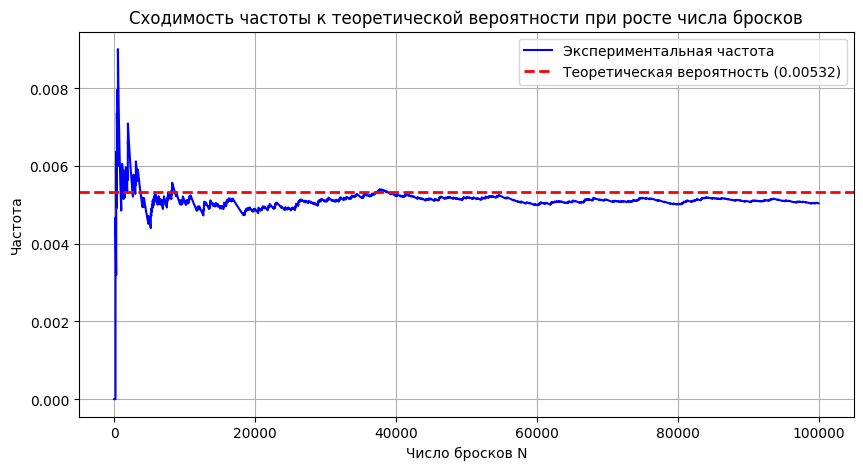

In [5]:
# График сходимости частоты к теории
N_sim = 100000
x_sim = np.random.uniform(bx, bx + bw, N_sim)
y_sim = np.random.uniform(by, by + bh, N_sim)
hits_sim = ((x_sim - x0)**2 + (y_sim - y0)**2) <= r_apple**2

freq_sim = np.cumsum(hits_sim) / np.arange(1, N_sim + 1)

plt.figure(figsize=(10, 5))
plt.plot(freq_sim, color='blue', lw=1.5, label='Экспериментальная частота')
plt.axhline(p_theor, color='red', linestyle='--', lw=2, label=f'Теоретическая вероятность ({p_theor:.5f})')
plt.title("Сходимость частоты к теоретической вероятности при росте числа бросков")
plt.xlabel("Число бросков N")
plt.ylabel("Частота")
plt.legend()
plt.grid(True)
plt.show()